# Chapter 6: Using a Neural Network to Fit the Data

### The PyTorch nn module

PyTorch has a whole submodule dedicated to neural networks, called torch.nn. It
contains the building blocks needed to create all sorts of neural network architectures. Those building blocks are called modules in PyTorch parlance (such building
blocks are often referred to as layers in other frameworks). A PyTorch module is a
Python class deriving from the nn.Module base class. A module can have one or more
nn.Parameter instances as attributes, which are tensors whose values are optimized
during the training process (think w and b in our linear model). A module can also
have one or more submodules (subclasses of nn.Module) as attributes, and it will be
able to track their parameters as well.

NOTE The submodules must be top-level attributes, not buried inside list or
dict instances! Otherwise, the optimizer will not be able to locate the submodules (and, hence, their parameters). For situations where your model
requires a list or dict of submodules, PyTorch provides nn.ModuleList and
nn.ModuleDict.

Unsurprisingly, we can find a subclass of nn.Module called nn.Linear, which applies an
affine transformation to its input (via the parameter attributes weight and bias) and is
equivalent to what we implemented earlier in our thermometer experiments. We’ll now
start precisely where we left off and convert our previous code to a form that uses nn.

### Using nn.Module as a callable

PyTorch’s nn.Module is designed to be used as a callable object, meaning it has its own
__call__ method defined. As a result, we can instantiate an nn.Linear and call it as if
it were a function:

In [1]:
import torch

# Prep data
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 6, 10,  1,  7,  2,  9,  5,  8,  0]), tensor([4, 3]))

In [2]:
# split data
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

In [3]:
import torch.nn as nn

linear_model = nn.Linear(1, 1)
linear_model(val_t_un.unsqueeze(1))

tensor([[5.5546],
        [8.0900]], grad_fn=<AddmmBackward0>)

Calling an instance of nn.Module with a set of arguments ends up calling a method
named forward with the same arguments. The forward method is what executes the forward computation, while __call__ does other rather important chores before and
after calling forward.

So, it is technically possible to call forward directly, and it will
produce the same output as __call__, but this should not be done from user code:

In [4]:
# y = model(x) # correct
# y = model.forward(x) # silent error

In some instances, PyTorch modules attach hooks, which are functions that can be
specified to be executed at specific times during the forward and backward passes.
These hooks can be defined by the user, or in some advanced use cases, the PyTorch
library itself will use them, for example, to implement a distributed training strategy.
If you call forward directly, the hooks won’t be executed, which may cause an error in
the program.

The constructor to nn.Linear accepts three arguments: the
number of input features, the number of output features, and whether the linear
model includes a bias (defaulting to True, here): linear_model = nn.Linear(1, 1)

The number of features in our case just refers to the size of the input and the output
tensor for the module, so 1 and 1. If we used both temperature and barometric pressure as input, for instance, we would have two features in input and one feature in output. As we will see, for more complex models with several intermediate modules, the
number of features is associated with the capacity of the model.

 We have an instance of nn.Linear with one input and one output feature. That
only requires one weight and one bias:

In [5]:
linear_model.weight

Parameter containing:
tensor([[0.9904]], requires_grad=True)

In [6]:
linear_model.bias

Parameter containing:
tensor([-0.0213], requires_grad=True)

We can call the module with some input:

In [7]:
x = torch.ones(1)
linear_model(x)

tensor([0.9691], grad_fn=<ViewBackward0>)

Although PyTorch lets us get away with it, we don’t actually provide an input with the
right dimensionality. We have a model that takes one input and produces one output,
but PyTorch’s nn.Module and its subclasses are designed to do so on multiple samples
at the same time. To accommodate multiple samples, modules expect the zeroth
dimension of the input to be the number of samples in the batch. We encountered this
concept in chapter 4, where we learned how to arrange real-world data into tensors.

### BATCHING INPUTS

Any module in nn is written to produce outputs for a batch of multiple inputs at the
same time. Thus, assuming we need to run nn.Linear on 10 samples, we can create an
input tensor of size B × N_in, where B is the size of the batch and N_in is the number
of input features, and run it once through the model. For example,

In [8]:
x = torch.ones(10, 1)
linear_model(x)

tensor([[0.9691],
        [0.9691],
        [0.9691],
        [0.9691],
        [0.9691],
        [0.9691],
        [0.9691],
        [0.9691],
        [0.9691],
        [0.9691]], grad_fn=<AddmmBackward0>)

### OPTIMIZING BATCHES
The reason we want to do this batching is multifaceted. One big motivation is to make
sure the computation we’re asking for is big enough to saturate the computing
resources we’re using to perform the computation. GPUs, in particular, are highly
parallelized, so a single input on a small model will leave most of the computing units
idle. By providing batches of inputs, the calculation can be spread across the otherwise idle units, which means the batched results come back just as quickly as a single
result would. Another benefit is that some advanced models use statistical information
from the entire batch, and those statistics get better with larger batch sizes.

 Back to our thermometer data: t_u and t_c were two 1D tensors of size B. Thanks
to broadcasting, we could write our linear model as w * x + b, where w and b are two
scalar parameters. This method works because we have a single input feature: if we
had two, we would need to add an extra dimension to turn that 1D tensor into a
matrix with samples in the rows and features in the columns.

 That’s exactly what we need to do to switch to using nn.Linear. We reshape our B
inputs to B × N_in , where N_in is 1. That is easily done with unsqueeze:

In [9]:
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

# Add a dimension to the tensors at index 1
t_c = torch.tensor(t_c).unsqueeze(1)
t_u = torch.tensor(t_u).unsqueeze(1)

In [10]:
t_c

tensor([[ 0.5000],
        [14.0000],
        [15.0000],
        [28.0000],
        [11.0000],
        [ 8.0000],
        [ 3.0000],
        [-4.0000],
        [ 6.0000],
        [13.0000],
        [21.0000]])

In [11]:
t_u.shape

torch.Size([11, 1])

Notice: these are matrix with 11 rows and 1 columns. They are no longer simply arrays.

In [12]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

We’re done; let’s update our training code. First, we replace our handmade model
with nn.Linear(1,1), and then we need to pass the linear model parameters to the
optimizer:

In [13]:
from torch import optim

linear_model = nn.Linear(1, 1)

optimizer = optim.SGD(
linear_model.parameters(),  # This method retrieves the model parameters. It replaces what we
                            # used as [params] in chapter 5.
lr=1e-2)

Earlier, it was our responsibility to create parameters and pass them as the first argument to optim.SGD. Now we can use the parameters method to ask any nn.Module for a
list of parameters owned by it or any of its submodules:

In [14]:
linear_model.parameters()

<generator object Module.parameters at 0x000002D8B188F680>

In [15]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[-0.4605]], requires_grad=True),
 Parameter containing:
 tensor([0.6312], requires_grad=True)]

This call recurses into submodules defined in the module’s init constructor and
returns a flat list of all parameters encountered, so that we can conveniently pass it to
the optimizer constructor as we did previously.

 We can already figure out what happens in the training loop. The optimizer is
provided with a list of tensors that were all defined with requires_grad = True. A
Parameter, which is just a subclass of a tensor and is specially recognized by nn.Module,
is defined as requiring gradients by default since they need to be optimized by gradient descent. When training_loss.backward() is called, grad is accumulated on the
leaf nodes of the graph, which are precisely the parameters that were passed to the
optimizer.

 At this point, the SGD optimizer has everything it needs. When optimizer.step()
is called, it will iterate through each Parameter and change it by an amount proportional to what is stored in its grad attribute. Pretty clean design.

 Let’s take a look at the training loop now:

In [16]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        # The model is now passed in, instead of the individual params.
        t_p_train = model(t_u_train)
        loss_train = loss_fn(t_p_train, t_c_train)
        t_p_val = model(t_u_val)
        loss_val = loss_fn(t_p_val, t_c_val)
        optimizer.zero_grad()

        # The loss function is also passed in.
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
    f" Validation loss {loss_val.item():.4f}")

The model hasn’t changed hardly at all, except that now we don’t pass params explicitly to model since the model itself holds its parameters internally.

 There’s one last bit that we can use from torch.nn: the loss. Indeed, nn comes with
several common loss functions, among them nn.MSELoss (MSE stands for mean
squared error), which is exactly what we defined earlier as our loss_fn. Loss functions
in nn are still subclasses of nn.Module, so we will create an instance and call it as a function. In our case, we get rid of the handwritten loss_fn and replace it:

In [19]:
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
n_epochs = 5000,
optimizer = optimizer,
model = linear_model,
loss_fn = nn.MSELoss(),
t_u_train = train_t_un,
t_u_val = val_t_un,
t_c_train = train_t_c,
t_c_val = val_t_c)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 240.4430, Validation loss 739.5271
Epoch 1000, Training loss 3.8732, Validation loss 8.6551
Epoch 2000, Training loss 2.9568, Validation loss 4.1884
Epoch 3000, Training loss 2.9133, Validation loss 3.5523
Epoch 4000, Training loss 2.9113, Validation loss 3.4297
Epoch 5000, Training loss 2.9112, Validation loss 3.4038

Parameter containing:
tensor([[5.1993]], requires_grad=True)
Parameter containing:
tensor([-16.4328], requires_grad=True)


Even our results remain
the same as before. Of course, getting the same results is expected, as a difference
would imply a bug in one of the two implementations.

### Finally, a neural network

In [20]:
# We chose 13 arbitrarily. We wanted a number that was a different size from the other
# tensor shapes we have floating around.
seq_model = nn.Sequential(
    nn.Linear(1, 13),
    nn.Tanh(),
    nn.Linear(13, 1))   # This 13 must match the first size, however.
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

The end result is a model that takes the inputs expected by the first module specified
as an argument of nn.Sequential, passes intermediate outputs to subsequent modules, and produces the output returned by the last module. The model fans out from
1 input feature to 13 hidden features, passes them through a tanh activation, and linearly combines the resulting 13 numbers into 1 output feature.



####  Inspecting the parameters

Calling model.parameters() will collect weight and bias from both the first and second linear modules. It’s instructive to inspect the parameters in this case by printing
their shapes:

In [21]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

These are the tensors that the optimizer will get. Again, after we call loss_train
.backward(), all parameters are populated with their grad, and the optimizer then
updates their values accordingly during the optimizer.step() call...

When inspecting parameters of a model
made up of several submodules, it is handy to be able to identify parameters by name.
There’s a method for that, called named_parameters:

In [23]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


NOTE You may have noticed that nn.Tanh is missing from our parameter list
despite being defined in the model. tanh, like most activation functions, does
not have any parameters. It is simply a fixed mathematical operation that
transforms the input in a predetermined way and thus is not tuned during
training like the linear layers.

The name of each module in Sequential is the ordinal with which the module
appears in the arguments. Interestingly, Sequential also accepts an OrderedDict, in
which we can name each module passed to Sequential:

In [24]:
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
('hidden_linear', nn.Linear(1, 8)),
('hidden_activation', nn.Tanh()),
('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

This way is more descriptive, but it does not give us more flexibility in the flow of
data through the network, which remains a purely sequential pass-through—the
nn.Sequential is very aptly named. **To achieve greater control and flexibility over how
data is processed—allowing for nonlinear data flows, custom layer interactions, or
conditional processing paths—you would need to create custom network architectures by subclassing nn.Module, which will be explored in chapter 8.**

 We can also access a particular Parameter by using submodules as attributes:

In [25]:
seq_model.output_linear.bias

Parameter containing:
tensor([-0.1044], requires_grad=True)

Accessing the Parameters is useful for inspecting parameters or their gradients—for
instance, to monitor gradients during training, as we did at the beginning of this
chapter. Say we want to print out the gradients of weight of the linear portion of the
hidden layer. We can run the training loop for the new neural network model and
then look at the resulting gradients after the last epoch:

In [27]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)  # we've dropped the
                                                        # learning rate to improve stability.
training_loop(
n_epochs = 5000,
optimizer = optimizer,
model = seq_model,
loss_fn = nn.MSELoss(),
t_u_train = train_t_un,
t_u_val = val_t_un,
t_c_train = train_t_c,
t_c_val = val_t_c)

print('output:', seq_model(val_t_un))
print('answer:', val_t_c)
print('hidden grad:', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 2.1822, Validation loss 9.6856
Epoch 1000, Training loss 2.1284, Validation loss 8.1271
Epoch 2000, Training loss 2.0899, Validation loss 7.0125
Epoch 3000, Training loss 2.0620, Validation loss 6.2012
Epoch 4000, Training loss 2.0418, Validation loss 5.6188
Epoch 5000, Training loss 2.0268, Validation loss 5.2257
output: tensor([[12.5565],
        [25.1666]], grad_fn=<AddmmBackward0>)
answer: tensor([[11.],
        [28.]])
hidden grad: tensor([[-0.0105],
        [ 0.0114],
        [ 0.0097],
        [ 0.0038],
        [ 0.0010],
        [ 0.0091],
        [ 0.0008],
        [-0.0059]])


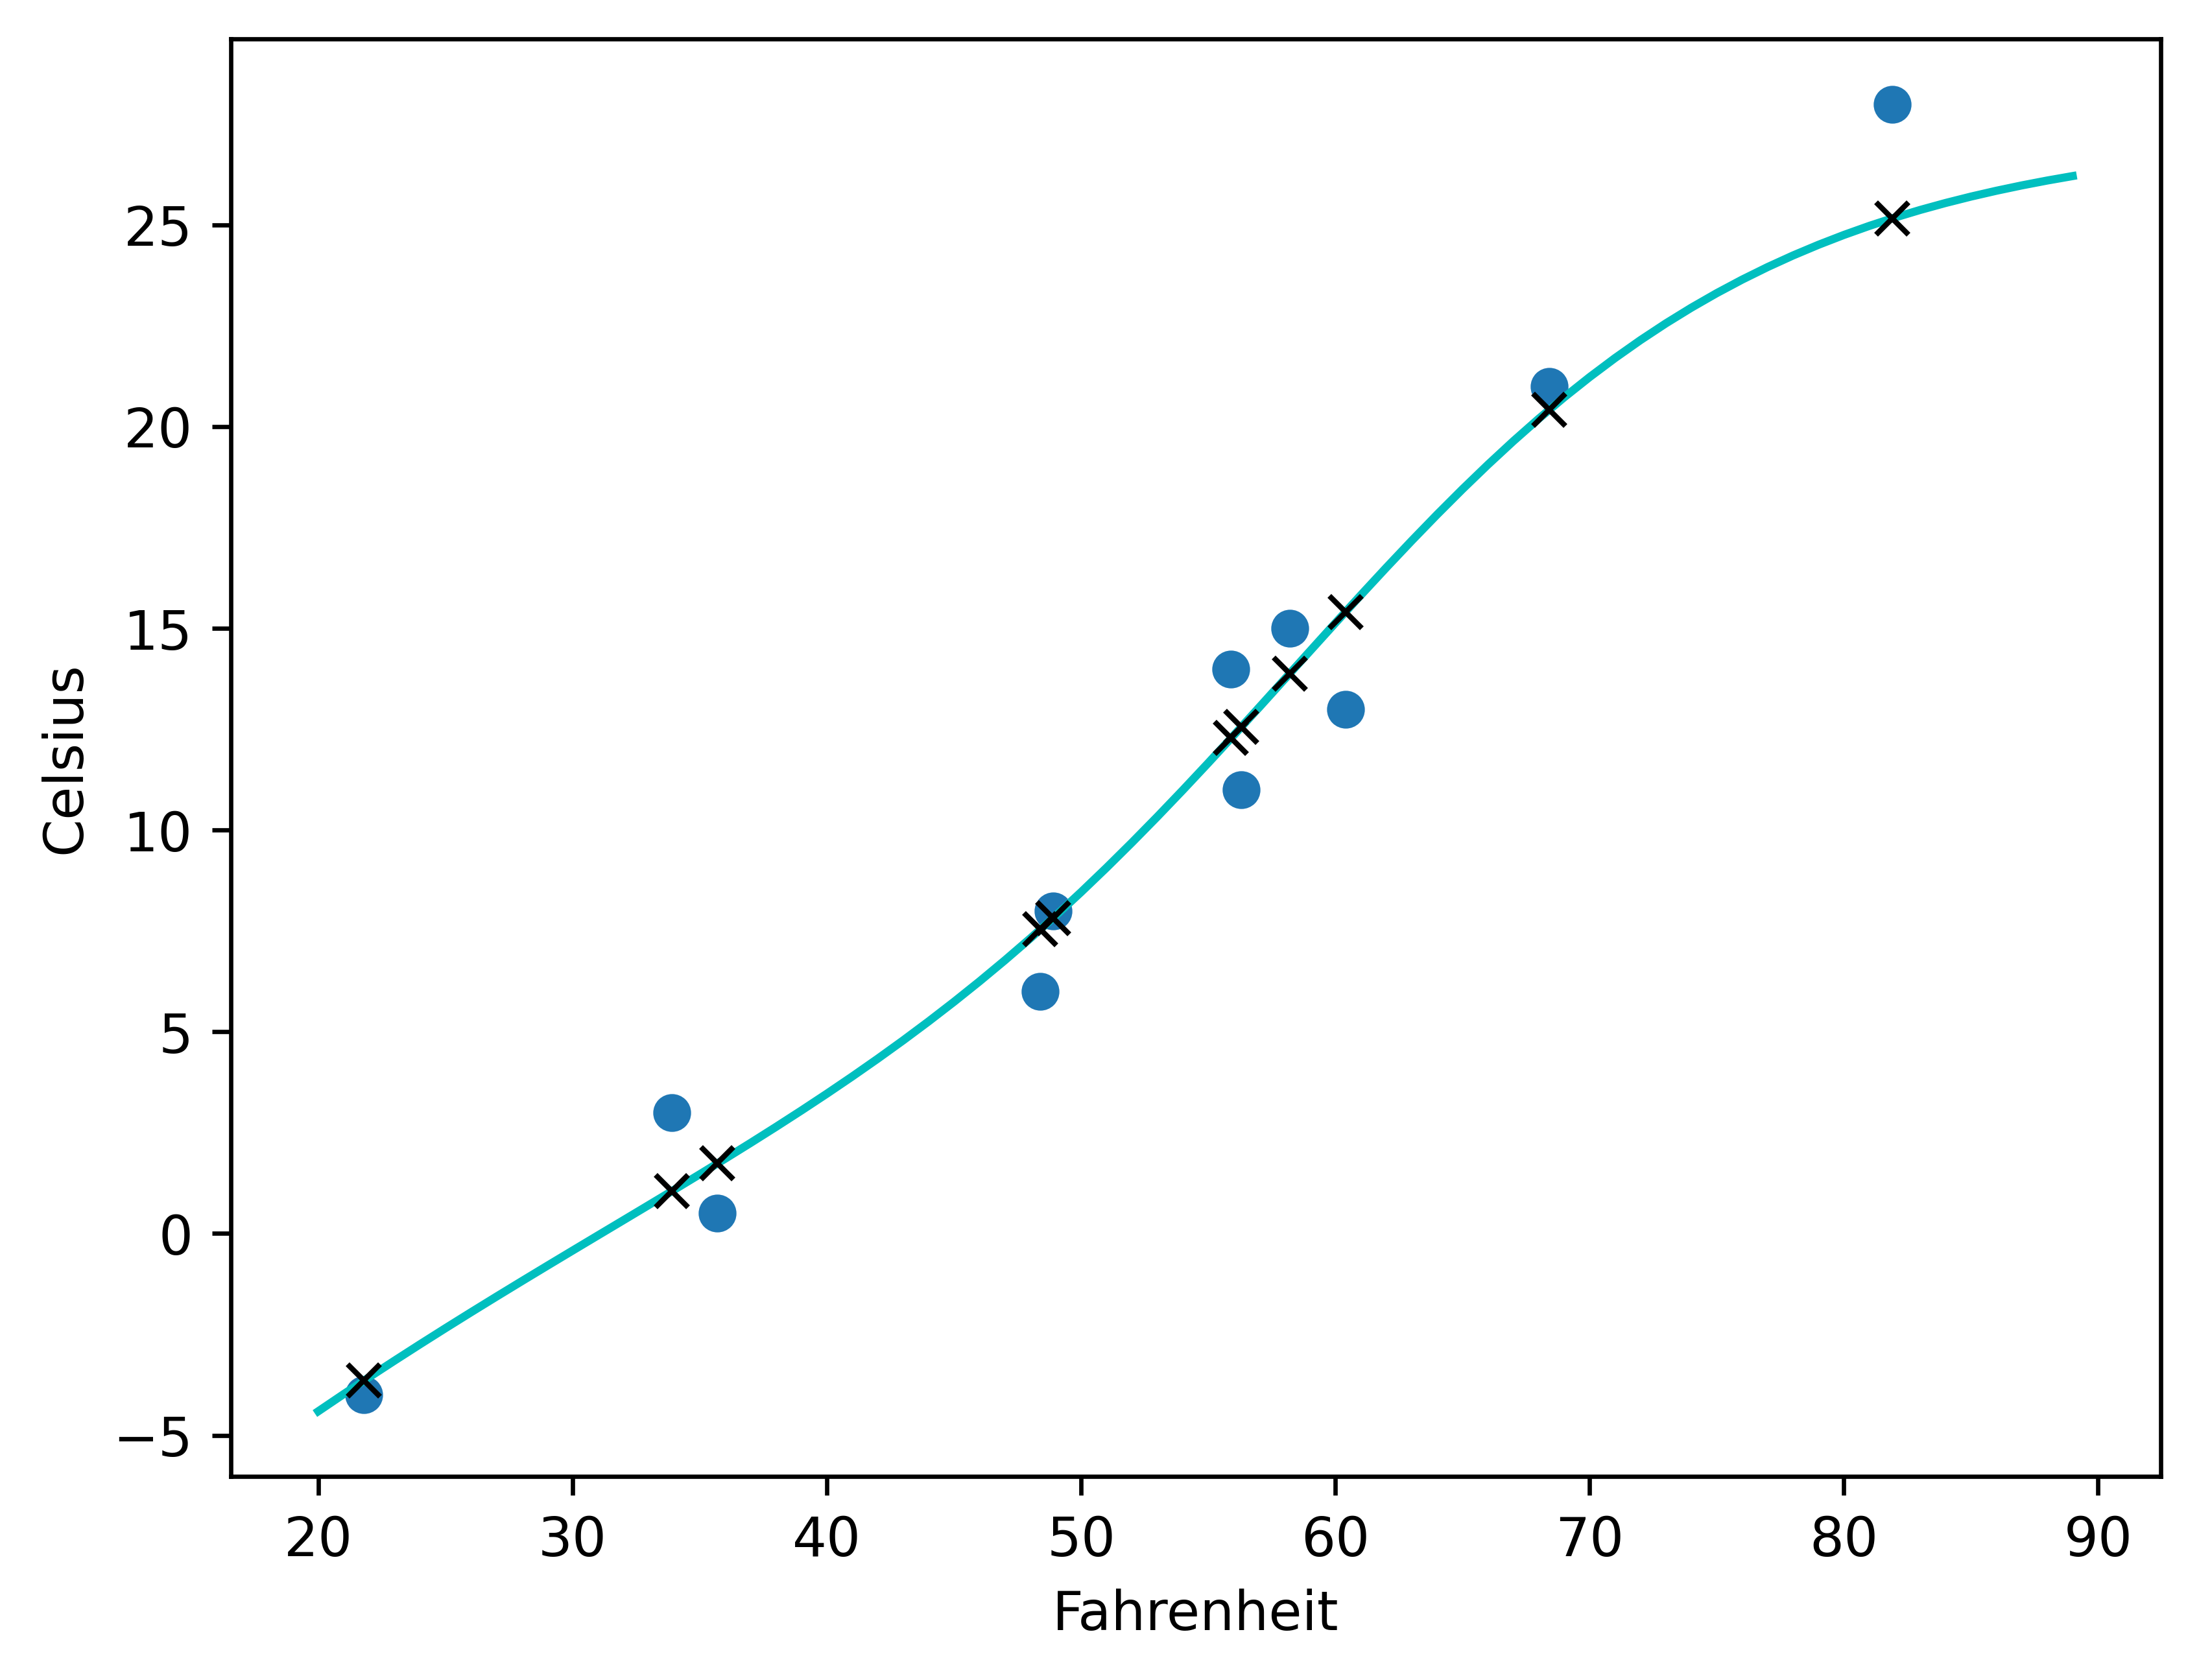

In [28]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)
fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')

We can appreciate that the neural network has a tendency to overfit, as we discussed in chapter 5, since it tries to chase the measurements,
including the noisy ones. Even our tiny neural network has too many parameters to fit
the few measurements we have. It doesn’t do a bad job, though, overall.
